# Lab 7- Data Analysis


## Exercise 1: Reading

### HiggsML
In 2014, some of my colleagues from the ATLAS experiment put together a Higgs Machine Learning Challenge, which was hosted on [Kaggle](https://www.kaggle.com). Please read sections 1 and 3 (skip/skim 2) of [The HiggsML Technical Documentation](https://higgsml.lal.in2p3.fr/files/2014/04/documentation_v1.8.pdf). 

Kaggle is a platform for data science competitions, with cash awards for winners. Kaggle currently hosts over 50,000 public datasets and associated competitions. Later in the course we will look at a variety of problems hosted on Kaggle and similar platforms. 

### SUSY Dataset

For the next few labs we will use datasets used in the [first paper on Deep Learning in High Energy physics](https://arxiv.org/pdf/1402.4735.pdf). Please read up to the "Deep Learning" section (end of page 5). This paper demonstrates that Deep Neural Networks can learn from raw data the features that are typically used by physicists for searches for exotics particles. The authors provide the data they used for this paper. They considered two benchmark scenarios: Higgs and SUSY.

## Exercise 2: Download SUSY Dataset

The information about the dataset can be found at the [UCI Machine Learning Repository](https://archive.ics.uci.edu/ml/index.php). We'll start with the [SUSY Dataset](https://archive.ics.uci.edu/ml/datasets/SUSY). 

### Download
In a terminal, download the data directly from the source and then decompress it. For example:

* To download:
    * On Mac OS: 
    `curl http://archive.ics.uci.edu/ml/machine-learning-databases/00279/SUSY.csv.gz > SUSY.csv.gz`

    * In linux:
    `wget http://archive.ics.uci.edu/ml/machine-learning-databases/00279/SUSY.csv.gz`

* To uncompress:
`gunzip SUSY.csv.gz`

In [1]:
#!curl http://archive.ics.uci.edu/ml/machine-learning-databases/00279/SUSY.csv.gz > SUSY.csv.gz

In [2]:
#!rm SUSY.csv

In [3]:
#!gunzip SUSY.csv.gz

In [4]:
ls -lh

total 1802528
-rw-r--r--   1 reelelsadig  staff   3.5K Feb 19 22:38 DATA3402_Lab3_Merge_Conflict_Guide.pdf
-rw-r--r--   1 reelelsadig  staff    55K Feb 19 22:38 Git Hub Setup Guide (wsl & Mac Os).pdf
drwxr-xr-x  11 reelelsadig  staff   352B Feb  5 20:21 Lab.2/
drwxr-xr-x   5 reelelsadig  staff   160B Feb 16 16:45 Lab.3/
drwxr-xr-x   5 reelelsadig  staff   160B Feb 20 15:46 Lab.4/
-rw-r--r--   1 reelelsadig  staff   441K Apr  3 15:58 Lab.7.ipynb
drwxr-xr-x   4 reelelsadig  staff   128B Feb 16 14:18 Labs.3/
-rw-r--r--   1 reelelsadig  staff     0B Mar 27 15:30 SUSY-small.csv
-rw-r--r--   1 reelelsadig  staff   880M Mar 27 15:30 SUSY.csv.gz


The data is provided as a comma separated file.

In [5]:
filename = "SUSY-small.csv"
# print out the first 5 lines using unix head command
!head -5  "SUSY.csv"

head: SUSY.csv: No such file or directory


## Reducing the dataset

This is a rather large dataset. If you have trouble loading it, we can easily make a new file with less data.

Here we look at the size of the data

In [6]:
!ls -lh

total 1802528
-rw-r--r--   1 reelelsadig  staff   3.5K Feb 19 22:38 DATA3402_Lab3_Merge_Conflict_Guide.pdf
-rw-r--r--   1 reelelsadig  staff    55K Feb 19 22:38 Git Hub Setup Guide (wsl & Mac Os).pdf
drwxr-xr-x  11 reelelsadig  staff   352B Feb  5 20:21 Lab.2
drwxr-xr-x   5 reelelsadig  staff   160B Feb 16 16:45 Lab.3
drwxr-xr-x   5 reelelsadig  staff   160B Feb 20 15:46 Lab.4
-rw-r--r--   1 reelelsadig  staff   441K Apr  3 15:58 Lab.7.ipynb
drwxr-xr-x   4 reelelsadig  staff   128B Feb 16 14:18 Labs.3
-rw-r--r--   1 reelelsadig  staff     0B Mar 27 15:30 SUSY-small.csv
-rw-r--r--   1 reelelsadig  staff   880M Mar 27 15:30 SUSY.csv.gz


We see that we have 5 million datapoints.

In [7]:
!wc -l SUSY.csv

wc: SUSY.csv: open: No such file or directory


We create a new file of the first half million. This is sufficient for our needs in this lab:

In [8]:
!head -500000 SUSY.csv > SUSY-small.csv

head: SUSY.csv: No such file or directory


In [9]:
import urllib.request

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00279/SUSY.csv.gz"
urllib.request.urlretrieve(url, "SUSY.csv.gz")

('SUSY.csv.gz', <http.client.HTTPMessage at 0x1038387d0>)

In [10]:
ls -lh

total 1801696
-rw-r--r--   1 reelelsadig  staff   3.5K Feb 19 22:38 DATA3402_Lab3_Merge_Conflict_Guide.pdf
-rw-r--r--   1 reelelsadig  staff    55K Feb 19 22:38 Git Hub Setup Guide (wsl & Mac Os).pdf
drwxr-xr-x  11 reelelsadig  staff   352B Feb  5 20:21 Lab.2/
drwxr-xr-x   5 reelelsadig  staff   160B Feb 16 16:45 Lab.3/
drwxr-xr-x   5 reelelsadig  staff   160B Feb 20 15:46 Lab.4/
-rw-r--r--   1 reelelsadig  staff    24K Apr  3 16:04 Lab.7.ipynb
drwxr-xr-x   4 reelelsadig  staff   128B Feb 16 14:18 Labs.3/
-rw-r--r--   1 reelelsadig  staff     0B Apr  3 15:59 SUSY-small.csv
-rw-r--r--   1 reelelsadig  staff   880M Apr  3 16:05 SUSY.csv.gz


In [11]:
!gunzip SUSY.csv.gz!

gunzip: can't stat: SUSY.csv.gz! (SUSY.csv.gz!.gz): No such file or directory


In [12]:
! wc -l SUSY-small.csv

       0 SUSY-small.csv


Use this file for the rest of the lab to make this run faster.

### First Look

Each row represents a LHC collision event. Each column contains some observable from that event. The variable names are ([based on documentation](https://archive.ics.uci.edu/ml/datasets/SUSY)):

In [13]:
VarNames=["signal", "l_1_pT", "l_1_eta","l_1_phi", "l_2_pT", "l_2_eta", "l_2_phi", "MET", "MET_phi", "MET_rel", "axial_MET", "M_R", "M_TR_2", "R", "MT2", "S_R", "M_Delta_R", "dPhi_r_b", "cos_theta_r1"]

Some of these variables represent the "raw" kinematics of the observed final state particles, while others are "features" that are derived from these raw quantities:

In [14]:
RawNames=["l_1_pT", "l_1_eta","l_1_phi", "l_2_pT", "l_2_eta", "l_2_phi", "MET", "MET_phi"]
FeatureNames=list(set(VarNames[1:]).difference(RawNames))

In [15]:
RawNames

['l_1_pT',
 'l_1_eta',
 'l_1_phi',
 'l_2_pT',
 'l_2_eta',
 'l_2_phi',
 'MET',
 'MET_phi']

In [16]:
FeatureNames

['dPhi_r_b',
 'S_R',
 'cos_theta_r1',
 'axial_MET',
 'M_R',
 'R',
 'MT2',
 'M_TR_2',
 'MET_rel',
 'M_Delta_R']

We will use pandas to read in the file, and matplotlib to make plots. The following ensures pandas is installed and sets everything up:

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

In [18]:
import pandas as pd
df = pd.read_csv(filename, header=None)

EmptyDataError: No columns to parse from file

In [ ]:
import pandas as pd

In [ ]:
VarNames = ["label",
            "lepton pT", "lepton eta", "lepton phi",
            "missing energy magnitude", "missing energy phi",
            "jet1 pt", "jet1 eta", "jet1 phi",
            "jet2 pt", "jet2 eta", "jet2 phi",
            "jet3 pt", "jet3 eta", "jet3 phi",
            "jet4 pt", "jet4 eta", "jet4 phi",
            "m_jj", "m_jjj", "m_lv", "m_jlv",
            "m_bb", "m_wbb", "m_wwbb"]

Now we can read the data into a pandas dataframe:

In [ ]:
filename = "SUSY-small.csv"
df = pd.read_csv(filename, dtype='float64', names=VarNames)

You can see the data in Jupyter by just evaluateing the dataframe:

In [ ]:
df

The first column stores the "truth" label of whether an event was signal or not. Pandas makes it easy to create dataframes that store only the signal or background events:

In [ ]:
df_sig=df[df.signal==1]
df_bkg=df[df.signal==0]

The following example plots the signal and background distributions of every variable. Note that we use VarNames[1:] to skip the first variable, which was the true label.

In [ ]:
import numpy as np
for var in VarNames[1:]:
    print (var)
    plt.figure(figsize=(10,5))
    plt.hist(np.array(df_sig[var]),bins=100,histtype="step", color="red",label="signal",density=1, stacked=True)
    plt.hist(np.array(df_bkg[var]),bins=100,histtype="step", color="blue", label="background",density=1, stacked=True)
    plt.legend(loc='upper right')
    plt.show()

## Exercise 3: Make nice figures

Now use `matplotlib` to reproduce as closely as you can figures 5 and 6 from the paper. This exercise is intended to get you to familiarize yourself with making nicely formatted `matplotlib` figures with multiple plots. Note that the plots in the paper are actually wrong!

In [ ]:
df_sig = df[df["label"] == 1]
df_bkg = df[df["label"] == 0]

## Exercise 4: Correlation

### Exercise 4.1

#### Part a
Write a function that creates pair plots and use it to compare variables in the SUSY sample, separately for low and high-level features. Refer to Lecture 13 for details. Do not use `seaborn`.

#### Part b
Making these plots can be slow because creating each plot initiates a full loop over the data. Make at least one modification to your function in part a to speed it up. Can you propose a different method of creating histograms that would speed up making such pair plots?

#### Part c
Which observables appear to be best for separating signal from background?

### Exercise 4.2

#### Part a
Install [tabulate](https://github.com/astanin/python-tabulate). 

#### Part b
Use numpy to compute the [covariance matrix](https://numpy.org/doc/stable/reference/generated/numpy.cov.html) and [correlation matrix](https://numpy.org/doc/stable/reference/generated/numpy.corrcoef.html) between all observabes, and separately between low and high-level features.

#### Part c
Use tabulate to create a well formatted table of the covariance and correlation matrices, with nice headings and appropriate significant figures. Embed the table into this notebook.

#### Part d
Write a function that takes a dataset and appropriate arguments and performs steps b and c.  

Hint: Example code for embedding a `tabulate` table into a notebook:

In [ ]:
import sys
!{sys.executable} -m pip install tabulate

In [ ]:
import sys
!{sys.executable} -m pip install tabulate

In [ ]:
from IPython.display import HTML, display
import tabulate
table = [["A",1,2],
        ["C",3,4],
        ["D",5,6]]
display(HTML(tabulate.tabulate(table, tablefmt='html', headers=["X","Y","Z"])))

In [ ]:
RawNames = VarNames[1:19]
FeatureNames = VarNames[19:]

In [ ]:
def pair_plot(df, variables):
    n = len(variables)
    fig, axes = plt.subplots(n, n, figsize=(10,10))

    for i in range(n):
        for j in range(n):
            if i ==j:
                axes[i,j].hist(df[variables[i]], bins=30)
            else:
                axes[i,j].scatter(df[variables[j]],
                                  df[variables[i]], s=1)
    plt.show()

In [ ]:
pair_plot(df_sig, RawNames[:4])
import numpy as np
corr = np.corrcoef(df[RawNames].values, rowvar=False)

In [ ]:
print(corr)

## Exercise 5: Selection

### Exercise 5.1

Part a
By looking at the signal/background distributions for each observable (e.g. $x$) determine which selection criteria would be optimal: 

1. $x > x_c$
2. $x < x_c$
3. $|x - \mu| > x_c$
4. $|x - \mu| < x_c$

where $x_c$ is value to be determined below.

### Exercise 5.2

Plot the True Positive Rate (TPR) (aka signal efficiency $\epsilon_S(x_c)$) and False Positive Rate (FPR) (aka background efficiency $\epsilon_B(x_c)$) as function of $x_c$ for applying the strategy in part a to each observable. 

### Exercise 5.3
Assume 3 different scenarios corresponding to different numbers of signal and background events expected in data:

1. Expect $N_S=10$, $N_B=100$.
1. Expect $N_S=100$, $N_B=1000$.
1. Expect $N_S=1000$, $N_B=10000$.
1. Expect $N_S=10000$, $N_B=100000$.

Plot the significance ($\sigma_{S'}$) for each observable as function of $x_c$ for each scenario, where 

$\sigma_{S'}= \frac{N'_S}{\sqrt{N'_S+N'_B}}$

and $N'_{S,B} = \epsilon_{S,B}(x_c) * N_{S,B}$.

In [ ]:
### Exercise 5
def compute_tpr_fpr(df, var):
    x_vals = np.linespace(df[var].min(), df[var].max(), 100)

    tpr = []
    fpr = []

    df_sig = df[df["label"] ==1]
    df_bkg = df[df["label"] ==0]

    for xc in x_vals:
        tpr.append(np.sum(df_sig[var] > xc) / len(df_sig))
        fpr.append(np.sum(df_bkg[var] > xc) / len(df_bkg))
    return x_vals, tpr, fpr

In [ ]:
import pandas as pd


In [ ]:
var = "lepton pt"
x, tpr, fpr = compute_tpr_fpr(df, var)
plt.plot(x, tpr, label="TPR (Signal Efficiency)")
plt.plot(x, tpr, label="FPR (Background Efficiency)")
plt.xlabel("Cut value xc")
plt.ylabel("Efficiency")
plt.legend()
plt.title(var)
plt.show()



## Exercise 6: Cut Flow


### Exercise 6.1

For each above scenario, choose a subset (minumum 3) of observables to use for selections, and values of $x_c$ based on your significance plots (part 3c). 

### Exercise 6.2
Create a "cut-flow" table for each scenario where you successively make the selections on each observable and tabulate $\epsilon_S$, $\epsilon_B$, $N'_S$, $N'_B$, and $\sigma_{S'}$.

### Exercise 6.3
In 3c above you computed the significance for each observable assuming to make no other selections on any other observable. If the variables are correlated, then this assumption can lead to non-optimial results when selecting on multiple variables. By looking at the correlation matrices and your answers to 4b, identify where this effect could be most detrimental to the significance. Attempt to correct the issue by applying the selection in one observable and then optimizing (part 3c) for a second observable. What happens if you change the order of your selection (make selection on second and optimize on first)?




In [22]:
vars_selected = [col for col in df.columns if col != "signal"]
cuts = [df[var].quantile(0.2) for var in vars_selected]
table = cut_flow(df, vars_selected, cuts)
print(table)

NameError: name 'df' is not defined

In [ ]:
print(df.head())
print(df.columns)


In [25]:
import os
print(os.listdir())

['.DS_Store', 'SUSY.csv.gz', 'Labs.3', 'DATA3402_Lab3_Merge_Conflict_Guide.pdf', 'Git Hub Setup Guide (wsl & Mac Os).pdf', 'Lab.7.ipynb', 'Lab.3', 'Lab.4', 'Lab.2', '.ipynb_checkpoints', 'SUSY-small.csv']


In [27]:
import pandas as pd

df = pd.read_csv("SUSY.csv.gz", compression="gzip", header=None)

print(df.head())
print(df.shape)

    0         1         2         3         4         5         6         7   \
0  0.0  0.972861  0.653855  1.176225  1.157156 -1.739873 -0.874309  0.567765   
1  1.0  1.667973  0.064191 -1.225171  0.506102 -0.338939  1.672543  3.475464   
2  1.0  0.444840 -0.134298 -0.709972  0.451719 -1.613871 -0.768661  1.219918   
3  1.0  0.381256 -0.976145  0.693152  0.448959  0.891753 -0.677328  2.033060   
4  1.0  1.309996 -0.690089 -0.676259  1.589283 -0.693326  0.622907  1.087562   

         8         9         10        11        12        13        14  \
0 -0.175000  0.810061 -0.252552  1.921887  0.889637  0.410772  1.145621   
1 -1.219136  0.012955  3.775174  1.045977  0.568051  0.481928  0.000000   
2  0.504026  1.831248 -0.431385  0.526283  0.941514  1.587535  2.024308   
3  1.533041  3.046260 -1.005285  0.569386  1.015211  1.582217  1.551914   
4 -0.381742  0.589204  1.365479  1.179295  0.968218  0.728563  0.000000   

         15        16        17        18  
0  1.932632  0.994464  1

In [ ]:
vars_selected = [col for col in df.columns if col != "signal"]
print(vars_selected)

In [28]:
df.columns = ["signal"] + [f"var{i}" for i in range(1, df.shape[1])]

print(df.head())

   signal      var1      var2      var3      var4      var5      var6  \
0     0.0  0.972861  0.653855  1.176225  1.157156 -1.739873 -0.874309   
1     1.0  1.667973  0.064191 -1.225171  0.506102 -0.338939  1.672543   
2     1.0  0.444840 -0.134298 -0.709972  0.451719 -1.613871 -0.768661   
3     1.0  0.381256 -0.976145  0.693152  0.448959  0.891753 -0.677328   
4     1.0  1.309996 -0.690089 -0.676259  1.589283 -0.693326  0.622907   

       var7      var8      var9     var10     var11     var12     var13  \
0  0.567765 -0.175000  0.810061 -0.252552  1.921887  0.889637  0.410772   
1  3.475464 -1.219136  0.012955  3.775174  1.045977  0.568051  0.481928   
2  1.219918  0.504026  1.831248 -0.431385  0.526283  0.941514  1.587535   
3  2.033060  1.533041  3.046260 -1.005285  0.569386  1.015211  1.582217   
4  1.087562 -0.381742  0.589204  1.365479  1.179295  0.968218  0.728563   

      var14     var15     var16     var17     var18  
0  1.145621  1.932632  0.994464  1.367815  0.040714  
1 

In [ ]:
cuts = [
    df[vars_selected[0]].quantile(0.5),
    df[vars_selected[1]].quantile(0.5),
    df[vars_selected[2]].quantile(0.5)
]

In [29]:
print(df.columns)

Index(['signal', 'var1', 'var2', 'var3', 'var4', 'var5', 'var6', 'var7',
       'var8', 'var9', 'var10', 'var11', 'var12', 'var13', 'var14', 'var15',
       'var16', 'var17', 'var18'],
      dtype='object')


In [32]:
import pandas as pd
df_table = pd.DataFrame(table, columns=[
    "Variable", "Cut", "Signal Eff", "Background Eff", "Signal Count", " Background Count"
])
df_table

NameError: name 'table' is not defined

## Exercise 7: ROC Curves

### Exercise 7.1
For the top 3 observables you identified earlier, create one figure overlaying the Reciever Operating Characteristic (ROC) curves for the 3 observables. Compute the area under the curves and report it in the legend of the figure.

### Exercise 7.2
Write a function that you can use to quickly create the figure in part a with other observables and different conditions. Note that you will likely revise this function as you do the remainder of the lab.

### Exercise 7.3
Use the function from part b to compare the ROC curves for the successive selections in lab 3, exercise 4. Specifically, plot the ROC curve after each selection.

### Exercise 7.4
Use your function and appropriate example to demonstrate the effect (if any) of changing order of the successive selections.



In [37]:
import numpy as np
def roc_curve(df, var):
    x_vals = np.linspace(df[var].min(), df[var].max(), 100)
    tpr = []
    fpr = []
    df_sig = df[df["signal"] == 1]
    df_bkg = df[df["signal"] == 0]

    for xc in x_vals:
        tpr.append(np.sum(df_sig[var] > xc) / len(df_sig))
        tpr.append(np.sum(df_bkg[var] > xc) / len(df_bkg))
    return fpr, tpr


In [39]:
print(df["signal"].unique())
print(df["signal"].value_counts())

[0. 1.]
signal
0.0    2712173
1.0    2287827
Name: count, dtype: int64


In [40]:
df["signal"] = df["signal"].astype(int)

/var/folders/j3/kyg3l4012n3_n0cftzbb2dv40000gn/T/ipykernel_78739/1137594225.py:5: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  auc = np.trapz(tpr, fpr)


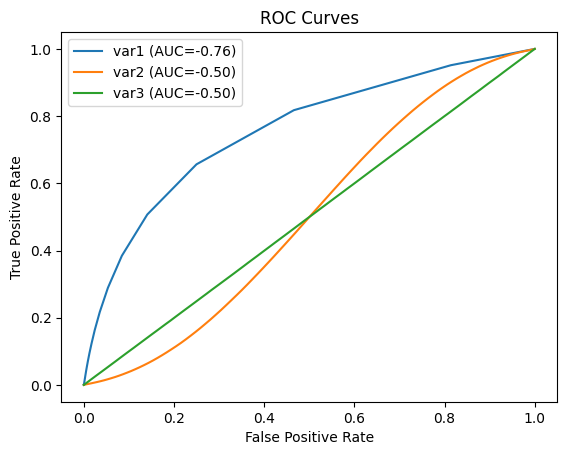

In [43]:
vars_selected = df.columns[1:4]
for var in vars_selected:
    fpr, tpr = roc_curve(df, var)

    auc = np.trapz(tpr, fpr)
    plt.plot(fpr, tpr, label=f"{var} (AUC={auc:.2f})")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves")
plt.legend()
plt.show()


In [42]:
import numpy as np

def roc_curve(df, var):
    x_vals = np.linspace(df[var].min(), df[var].max(), 100)
    
    tpr = []
    fpr = []
    
    df_sig = df[df["signal"] == 1]
    df_bkg = df[df["signal"] == 0]
    
    for xc in x_vals:
        tpr.append(np.sum(df_sig[var] > xc) / len(df_sig))
        fpr.append(np.sum(df_bkg[var] > xc) / len(df_bkg))
    
    return fpr, tpr

## Exercise 8: Linear Discriminant

### Exercise 8.1

Using numpy, compute the between-class $\bf{S}_B$ and within-class $\bf{S}_W$ covariance matrices defined as:

$$
\bf{S}_B = (\bf{m_2}-\bf{m_1})(\bf{m_2}-\bf{m_1})^T \\
$$
$$
\bf{S}_W = \sum_{i=1,2} \sum_{n=1}^{l_i} (\bf{x}_n^i - \bf{m}_i) (\bf{x}_n^i - \bf{m}_i)^T
$$

where $\bf{m_i}$ are the vectors containing the means for category 1 and 2, here defined as signal and background. Here $\bf{x}_n^i$ is the vector containing the observables for the $n$th example event in category $i$.

### Exercise 8.1

Compute the linear coefficients $\bf{w} = \bf{S_W}^{-1}(\bf{m_2}-\bf{m_1})$. Compare the histogram of the distribution of $F_n^i=\bf{w}^T\bf{x}_n^i$ for the two categories.

### Exercise 8.1

Draw the ROC curve for $F_n$. 

### Exercise 8.1

What is the maximal significance you can obtain in the scenarios in exercise 5? 

In [44]:
features = df.columns[1:5]
X_sig = df[df["signal"] == 1] [features].values
X_bkg = df[df["signal"] == 0] [features].values


In [45]:
import numpy as np
m1= np.mean(X_sig, axis=0)
m2= np.mean(X_bkg, axis=0)

In [48]:
S_B = np.outer((m2 - m1), (m2 - m1))


In [ ]:
S_W = np.zeros((len(features), len(features)))
for x in X_sig:
    diff = (x - m1).reshape(-1,1)
    S_W += diff @ dif